In [53]:
!pip install scikit-learn xgboost seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [55]:
df = pd.read_csv(
    "data/processed/processed_data.csv"
)

df.head()

C:\Users\jay\AppData\Local\Temp\ipykernel_11712\3402409996.py:1: DtypeWarning: Columns (0: Accident_Index) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,Accident_Index,1st_Road_Number,2nd_Road_Number,Accident_Severity,Did_Police_Officer_Attend_Scene_of_Accident,Latitude,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,...,Junction_Detail_Private Drive Or Entrance,Junction_Detail_Roundabout,Junction_Detail_Slip Road,Junction_Detail_T Or Staggered Junction,Junction_Detail_Unknown,Number_of_Casualties_Outlier,Age_of_Vehicle_mean_Outlier,Road_Risk_Score_Outlier,Number_of_Vehicles_Outlier,Speed_limit_Outlier
0,200501Bs00001,3218.0,0.0,Serious,1.0,51.489096,182,89,525680.0,178240.0,...,0,0,0,0,0,False,False,False,False,False
1,200501Bs00002,450.0,0.0,Slight,1.0,51.520075,182,89,524170.0,181650.0,...,0,0,0,0,0,False,False,False,False,False
2,200501Bs00003,0.0,0.0,Slight,1.0,51.525301,182,89,524520.0,182240.0,...,0,0,0,0,0,False,False,False,False,False
3,200501Bs00004,3220.0,0.0,Slight,1.0,51.482442,182,89,526900.0,177530.0,...,0,0,0,0,0,False,False,False,False,False
4,200501Bs00005,0.0,0.0,Slight,1.0,51.495752,182,89,528060.0,179040.0,...,0,0,0,0,0,False,False,False,False,False


In [56]:
df.shape

(2047244, 130)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047244 entries, 0 to 2047243
Columns: 130 entries, Accident_Index to Speed_limit_Outlier
dtypes: bool(5), float64(23), int64(100), object(1), str(1)
memory usage: 1.9+ GB


In [58]:
df.describe()

,1st_Road_Number,2nd_Road_Number,Did_Police_Officer_Attend_Scene_of_Accident,Latitude,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,...,Junction_Detail_Crossroads,Junction_Detail_Mini-Roundabout,Junction_Detail_More Than 4 Arms (Not Roundabout),Junction_Detail_Not At Junction Or Within 20 Metres,Junction_Detail_Other Junction,Junction_Detail_Private Drive Or Entrance,Junction_Detail_Roundabout,Junction_Detail_Slip Road,Junction_Detail_T Or Staggered Junction,Junction_Detail_Unknown
count,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,...,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06,2.047244e+06
mean,9.921093e+02,3.696134e+02,1.202292e+00,5.255975e+01,2.021731e+02,1.010630e+02,4.414463e+05,2.968827e+05,-1.410152e+00,1.838272e+04,...,9.587621e-02,1.094496e-02,1.248068e-02,4.040627e-01,2.915725e-02,3.553607e-02,8.656223e-02,1.467876e-02,3.103426e-01,3.585308e-04
std,1.809411e+03,1.282716e+03,4.081735e-01,1.445450e+00,1.195180e+02,5.782732e+01,9.549247e+04,1.605213e+05,1.403474e+00,1.067828e+04,...,2.944215e-01,1.040441e-01,1.110177e-01,4.907099e-01,1.682472e-01,1.851304e-01,2.811925e-01,1.202635e-01,4.626339e-01,1.893152e-02
min,0.000000e+00,0.000000e+00,1.000000e+00,4.991294e+01,0.000000e+00,0.000000e+00,6.495000e+04,1.029000e+04,-7.516225e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,1.000000e+00,5.148541e+01,1.000000e+02,5.300000e+01,3.780722e+05,1.777600e+05,-2.329505e+00,9.038000e+03,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.180000e+02,0.000000e+00,1.000000e+00,5.223759e+01,1.950000e+02,9.600000e+01,4.430500e+05,2.611850e+05,-1.362233e+00,1.860400e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,7.020000e+02,0.000000e+00,1.000000e+00,5.345586e+01,3.050000e+02,1.520000e+02,5.242900e+05,3.956100e+05,-2.052988e-01,2.798200e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,9.999000e+03,9.999000e+03,3.000000e+00,6.075754e+01,4.150000e+02,2.060000e+02,6.555400e+05,1.208800e+06,1.762010e+00,3.556400e+04,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [59]:
df.columns

Index(['Accident_Index', '1st_Road_Number', '2nd_Road_Number',
       'Accident_Severity', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'Latitude', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'Location_Easting_OSGR', 'Location_Northing_OSGR',
       ...
       'Junction_Detail_Private Drive Or Entrance',
       'Junction_Detail_Roundabout', 'Junction_Detail_Slip Road',
       'Junction_Detail_T Or Staggered Junction', 'Junction_Detail_Unknown',
       'Number_of_Casualties_Outlier', 'Age_of_Vehicle_mean_Outlier',
       'Road_Risk_Score_Outlier', 'Number_of_Vehicles_Outlier',
       'Speed_limit_Outlier'],
      dtype='str', length=130)

In [60]:
if "Accident_Index" in df.columns:
    df = df.drop("Accident_Index", axis=1)

In [62]:
X = df.drop(
    "Accident_Severity",
    axis=1
)

y = df["Accident_Severity"]

In [63]:
X.dtypes

1st_Road_Number                                float64
2nd_Road_Number                                float64
Did_Police_Officer_Attend_Scene_of_Accident    float64
Latitude                                       float64
Local_Authority_(District)                       int64
                                                ...   
Number_of_Casualties_Outlier                      bool
Age_of_Vehicle_mean_Outlier                       bool
Road_Risk_Score_Outlier                           bool
Number_of_Vehicles_Outlier                        bool
Speed_limit_Outlier                               bool
Length: 128, dtype: object

In [64]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [65]:
X = X.fillna(
    X.median()
)

In [66]:
X = X.astype(int)

In [67]:
X.isnull().sum().sum()

np.int64(0)

In [68]:
y.value_counts()

Accident_Severity
Slight     1734547
Serious     286333
Fatal        26364
Name: count, dtype: int64

In [69]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Fatal' 'Serious' 'Slight']


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [71]:
print(set(y_train))

{np.int64(0), np.int64(1), np.int64(2)}


In [72]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [73]:
rf_pred = rf.predict(X_test)

In [74]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

In [75]:
xgb_pred = xgb.predict(X_test)

In [76]:
results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "F1_Score":[
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]

})


results

,Model,Accuracy,F1_Score
0,Random Forest,0.811894,0.793354
1,XGBoost,0.848135,0.783683


In [77]:
results.to_csv(
    "results/model_comparison.csv",
    index=False
)

In [78]:
print(
classification_report(
    y_test,
    rf_pred,
    target_names=[
        "Fatal",
        "Serious",
        "Slight"
    ]
))

              precision    recall  f1-score   support

       Fatal       0.12      0.01      0.01      5273
     Serious       0.30      0.21      0.25     57267
      Slight       0.87      0.92      0.89    346909

    accuracy                           0.81    409449
   macro avg       0.43      0.38      0.39    409449
weighted avg       0.78      0.81      0.79    409449



In [79]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[    37   1724   3512]
 [    89  12227  44951]
 [   175  26569 320165]]


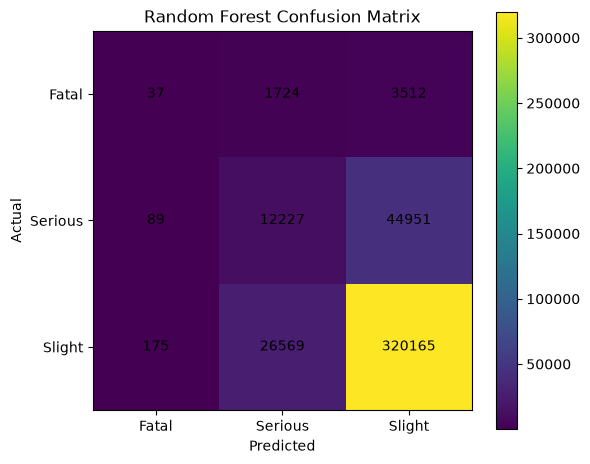

In [81]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

classes = [
    "Fatal",
    "Serious",
    "Slight"
]

plt.xticks(
    range(3),
    classes
)

plt.yticks(
    range(3),
    classes
)


plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Random Forest Confusion Matrix"
)


for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i][j],
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.savefig(
    "results/confusion_matrix.png",
    dpi=300
)

plt.show()

In [82]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    rf.feature_importances_

})


importance = importance.sort_values(
    "Importance",
    ascending=False
)


top_features = importance.head(15)

top_features

,Feature,Importance
6,Location_Easting_OSGR,0.052468
7,Location_Northing_OSGR,0.052020
9,LSOA_of_Accident_Location,0.048899
4,Local_Authority_(District),0.041190
0,1st_Road_Number,0.039752
19,Engine_Capacity_.CC._mean,0.036112
5,Local_Authority_(Highway),0.036079
28,Hour,0.034603
20,Engine_Capacity_.CC._max,0.034385
14,Police_Force,0.028039


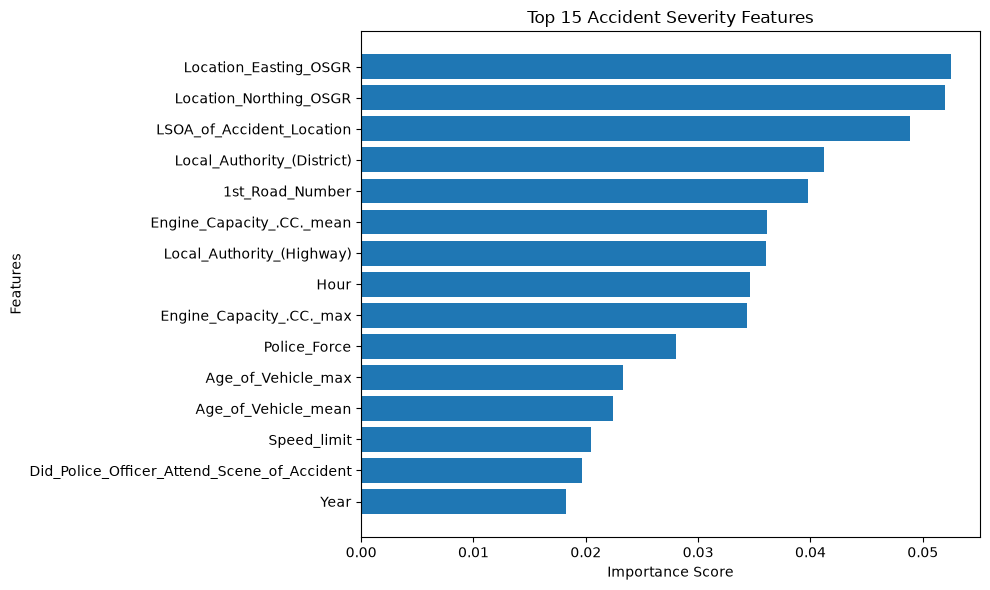

In [83]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.title(
    "Top 15 Accident Severity Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "results/feature_importance.png",
    dpi=300
)

plt.show()

In [85]:
pickle.dump(
    rf,
    open(
        "models/accident_severity_model.pkl",
        "wb"
    )
)

In [86]:
pickle.dump(
    encoder,
    open(
        "models/severity_encoder.pkl",
        "wb"
    )
)